# Car Dataset Exploratory Data Analysis

## Introduction

Used cars are one of the most actively traded goods in the world, 
yet pricing them accurately is complex — two cars of the same age 
can have vastly different values based on mileage, condition, brand, 
accident history, and other factors. Understanding what actually 
drives used car prices can help buyers identify fair deals, sellers 
price vehicles competitively, and dealerships understand market trends.

This analysis works with a 50,000-row, 25-column dataset sourced 
from Kaggle. The scope was deliberately narrowed to used and damaged 
fuel-powered vehicles by removing new cars and electric vehicles — 
this focus allows for a more meaningful analysis of the factors that 
affect real-world resale value.

### The key questions this analysis answers:
- Does brand matter more than mileage when pricing a used car?
- How significantly does accident history reduce value?
- Do features like transmission or insurance status have any real impact?
- Which features act as price ceilings vs price floors?

Both univariate and bivariate/multivariate analyses were performed 
using histograms, scatter plots, box plots, line plots, and heatmaps 
across quantitative and qualitative features.

## Objectives:

- Understand dataset structure
- Detect data quality issues
- Clean the data
- Analyze relationships
- Generate insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/car_price_dataset.csv")

# Information:

In [3]:
pd.set_option('display.max_columns', None)
df.head(20)

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,Transmission,DriveType,BodyType,Doors,Seats,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,513,395,Manual,AWD,Sedan,4,4,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,No,Valid,Incomplete,11.96,0.05,13884
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,302,270,Manual,FWD,Sedan,4,5,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,Yes,Expired,Incomplete,8.74,1.90,38888
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,400,388,Automatic,AWD,SUV,5,7,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,Yes,Valid,Complete,15.68,0.63,33074
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,187,219,Automatic,FWD,SUV,5,5,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,No,Expired,Complete,9.45,0.14,12966
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,90,112,Automatic,FWD,Hatchback,3,4,Red,Leather,"Heated Seats, Touchscreen",Delhi,No,Valid,Complete,7.16,0.01,2670
5,Porsche,911 Carrera,2018,7,Used,110968,3.3,Gasoline,565,392,Automatic,AWD,Coupe,2,2,White,Cloth,Sunroof,Paris,No,Expired,Incomplete,12.69,0.43,47830
6,Mercedes-Benz,S-Class,2019,6,Used,82607,5.8,Hybrid,509,750,Manual,RWD,Sedan,4,5,Silver,Cloth,"Navigation, Parking Sensors, Touchscreen",Los Angeles,Yes,Expired,Complete,17.83,0.62,51189
7,Porsche,Panamera,2014,11,Used,163074,3.5,Gasoline,513,428,Manual,RWD,Sedan,4,4,Red,Cloth,"Bluetooth, Touchscreen, Cruise Control, Heated...",Tokyo,No,Valid,Complete,13.06,0.17,27296
8,Audi,Q7,2007,18,Used,274471,2.0,Gasoline,315,277,Automatic,AWD,SUV,5,7,Red,Leather,"Touchscreen, Bluetooth",Tokyo,Yes,Expired,Incomplete,10.38,0.02,5389
9,Ford,Mustang,2019,6,Used,95498,4.6,Gasoline,364,588,Manual,RWD,Coupe,2,2,Red,Cloth,"Touchscreen, Cruise Control, Navigation, Bluet...",Berlin,Yes,Valid,Complete,14.90,0.11,10704


In [4]:
df.shape

(50000, 25)

In [5]:
df.dtypes

Brand                          str
Model                          str
Year                         int64
CarAge                       int64
Condition                      str
Mileage(km)                  int64
EngineSize(L)              float64
FuelType                       str
Horsepower                   int64
Torque                       int64
Transmission                   str
DriveType                      str
BodyType                       str
Doors                        int64
Seats                        int64
Color                          str
Interior                       str
Options                        str
City                           str
AccidentHistory                str
Insurance                      str
RegistrationStatus             str
FuelEfficiency(L/100km)    float64
PricePerKm                 float64
Price($)                     int64
dtype: object

In [6]:
df.isnull().sum()

Brand                         0
Model                         0
Year                          0
CarAge                        0
Condition                     0
Mileage(km)                   0
EngineSize(L)                 0
FuelType                      0
Horsepower                    0
Torque                        0
Transmission                  0
DriveType                     0
BodyType                      0
Doors                         0
Seats                         0
Color                         0
Interior                      0
Options                       0
City                          0
AccidentHistory               0
Insurance                     0
RegistrationStatus            0
FuelEfficiency(L/100km)       0
PricePerKm                 2459
Price($)                      0
dtype: int64

In [7]:
missing=df.isnull().mean()*100
print(missing.sort_values(ascending=False))

PricePerKm                 4.918
Model                      0.000
Year                       0.000
CarAge                     0.000
Condition                  0.000
Mileage(km)                0.000
EngineSize(L)              0.000
FuelType                   0.000
Brand                      0.000
Horsepower                 0.000
Torque                     0.000
DriveType                  0.000
Transmission               0.000
Doors                      0.000
Seats                      0.000
Color                      0.000
BodyType                   0.000
Interior                   0.000
Options                    0.000
AccidentHistory            0.000
City                       0.000
Insurance                  0.000
RegistrationStatus         0.000
FuelEfficiency(L/100km)    0.000
Price($)                   0.000
dtype: float64


# Cleaning:

### Making all the columns lower case and removing extra spaces

In [8]:
df.columns=(df.columns.str.lower().str.strip())

### Renaming of the columns

In [9]:
df = df.rename(columns={"enginesize(l)": "enginesize"})
df = df.rename(columns={"fuelefficiency(l/100km)": "fuelefficiency"})
df = df.rename(columns={"price($)": "price"})
df = df.rename(columns={"mileage(km)": "mileage"})

### Defining Scope
- We are removing rows with missing priceperkm because we only want to deal with old cars.
- Since out of 2,459 missing priceperkm values, 2,454 belong to New cars, and only 5 belong to 
- Used cars, that is why we are dropping these rows, which will remove all New cars (out of scope)
- We also removed the rows having fuel type as electric, since we only wanted to analyze cars running on fuels.
- This led to shrinking our 50000 rows into 42708 rows.

In [10]:
df['condition'].value_counts()

condition
Used       42767
Damaged     4779
New         2454
Name: count, dtype: int64

In [11]:
df=df.dropna(subset="priceperkm")

In [12]:
df['condition'].value_counts()

condition
Used       42762
Damaged     4779
Name: count, dtype: int64

In [13]:
df["fueltype"].value_counts()

fueltype
Gasoline    30799
Hybrid       9875
Electric     4833
Diesel       2034
Name: count, dtype: int64

In [14]:
df = df[df["fueltype"] != "Electric"]

In [15]:
df["fueltype"].value_counts()

fueltype
Gasoline    30799
Hybrid       9875
Diesel       2034
Name: count, dtype: int64

In [16]:
df.shape

(42708, 25)

### Mean, Median and other important calculations

In [17]:
df.describe()

,year,carage,mileage,enginesize,horsepower,torque,doors,seats,fuelefficiency,priceperkm,price
count,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000
mean,2014.483680,10.516320,157748.894985,2.366863,260.255971,307.219865,4.111478,4.682191,10.400359,0.297851,14007.066006
std,5.768721,5.768721,86676.836561,0.935592,126.893769,125.159146,0.993767,1.102019,2.738619,0.837763,14642.742710
min,2005.000000,1.000000,1081.000000,0.900000,65.000000,16.000000,2.000000,2.000000,5.000000,0.000000,1249.000000
25%,2010.000000,6.000000,82781.250000,1.700000,174.000000,217.000000,4.000000,5.000000,8.270000,0.020000,4568.000000
50%,2014.000000,11.000000,158526.000000,2.200000,226.000000,290.000000,4.000000,5.000000,10.180000,0.060000,9135.000000
75%,2019.000000,15.000000,232639.750000,2.900000,364.000000,385.000000,5.000000,5.000000,12.210000,0.210000,17492.250000
max,2024.000000,20.000000,320262.000000,6.000000,581.000000,850.000000,5.000000,7.000000,21.180000,34.560000,117598.000000


### Using mapping dictionary to change simple binary values into booleans

In [18]:
bool_map={'Yes':True,'No':False}
bool_map2={'Valid':True,'Expired':False}
bool_map3={'Incomplete':True,'Complete':False}
df["accidenthistory"]=df["accidenthistory"].map(bool_map)
df["insurance"]=df["insurance"].map(bool_map2)
df["registrationstatus"]=df["registrationstatus"].map(bool_map3)

## Final Cleansed Data

In [19]:
df.head()

,brand,model,year,carage,condition,mileage,enginesize,fueltype,horsepower,torque,transmission,drivetype,bodytype,doors,seats,color,interior,options,city,accidenthistory,insurance,registrationstatus,fuelefficiency,priceperkm,price
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,513,395,Manual,AWD,Sedan,4,4,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,False,True,True,11.96,0.05,13884
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,302,270,Manual,FWD,Sedan,4,5,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,True,False,True,8.74,1.90,38888
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,400,388,Automatic,AWD,SUV,5,7,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,True,True,False,15.68,0.63,33074
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,187,219,Automatic,FWD,SUV,5,5,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,False,False,False,9.45,0.14,12966
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,90,112,Automatic,FWD,Hatchback,3,4,Red,Leather,"Heated Seats, Touchscreen",Delhi,False,True,False,7.16,0.01,2670


In [20]:
df.shape

(42708, 25)

### Note: we left options column untouched but we may clean it in future

# Univariate Analysis:

## Price
- We can clearly see that the maximum value is far greater than the values in the middle, while the minimum value is closer to the middle.
- So these values suggest that some expensive cars are making the average car price appear to be more expensive.
- That is why, instead of taking the mean as an average for price, we will take it as a median since it's the middle of the data.
- The mean shows there are outliers, and the graph is also right-skewed, showing expensive cars as outliers.

In [21]:
df['price'].describe()

count     42708.000000
mean      14007.066006
std       14642.742710
min        1249.000000
25%        4568.000000
50%        9135.000000
75%       17492.250000
max      117598.000000
Name: price, dtype: float64

In [22]:
sns.set_theme(style="darkgrid")
sns.set_palette("dark")

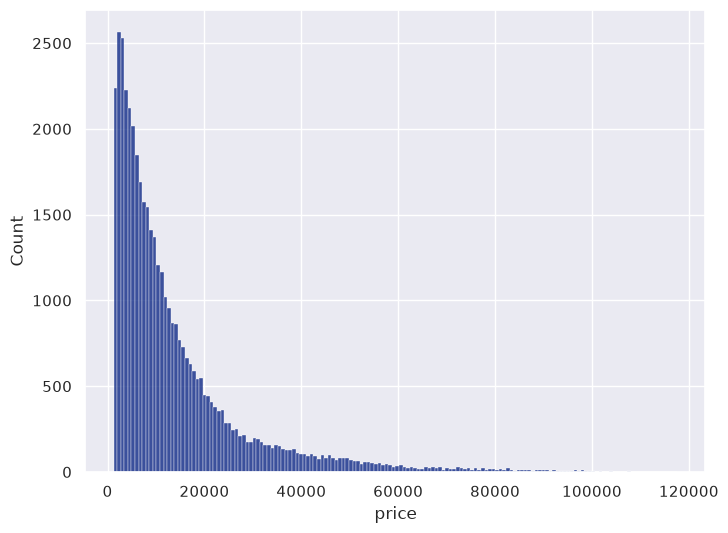

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(df["price"]);

---

## Fuel Efficiency:
- The average fuel efficiency of a car is 10.
- The maximum fuel efficiency is 21, while the lowest is 5

In [24]:
df['fuelefficiency'].describe()

count    42708.000000
mean        10.400359
std          2.738619
min          5.000000
25%          8.270000
50%         10.180000
75%         12.210000
max         21.180000
Name: fuelefficiency, dtype: float64

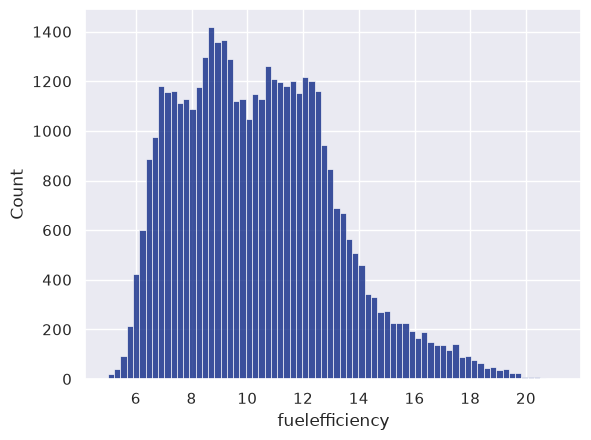

In [25]:
sns.histplot(df["fuelefficiency"]);

---

## Horsepower
- The maximum horsepower is 581, while the lowest is 64
- There is no average horsepower because it varies according to the body type
- We see multimodal distribution in our visualization, which further shows there are peaks in clusters, indicating that there is no single average

In [26]:
df["horsepower"].describe()

count    42708.000000
mean       260.255971
std        126.893769
min         65.000000
25%        174.000000
50%        226.000000
75%        364.000000
max        581.000000
Name: horsepower, dtype: float64

In [27]:
df.groupby("bodytype")["horsepower"].mean().sort_values()

bodytype
Hatchback      117.789959
Convertible    181.000000
SUV            265.347239
Sedan          304.737362
Pickup         386.473146
Coupe          402.576321
Name: horsepower, dtype: float64

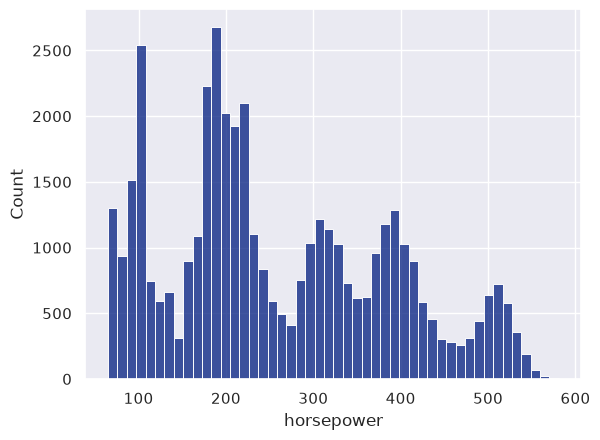

In [28]:
sns.histplot(df["horsepower"]);

---

## Engine Size

- Skipped as a separate deep univariate writeup because enginesize is also driven largely by bodytype (same groupby pattern as horsepower)
- Hatchback lowest at 1.30L to Pickup highest at 3.82L.
- However, unlike horsepower, mean (2.37) and median (2.20) here are close, suggesting the spread is less skewed despite still being multimodal
- bodytype explains the clusters, but doesn't pull the average as far off-center as it did for horsepower.

In [29]:
df["enginesize"].describe()

count    42708.000000
mean         2.366863
std          0.935592
min          0.900000
25%          1.700000
50%          2.200000
75%          2.900000
max          6.000000
Name: enginesize, dtype: float64

In [30]:
df.groupby("bodytype")["enginesize"].mean().sort_values()

bodytype
Hatchback      1.301647
Convertible    2.000000
SUV            2.543124
Sedan          2.660963
Coupe          3.156475
Pickup         3.816240
Name: enginesize, dtype: float64

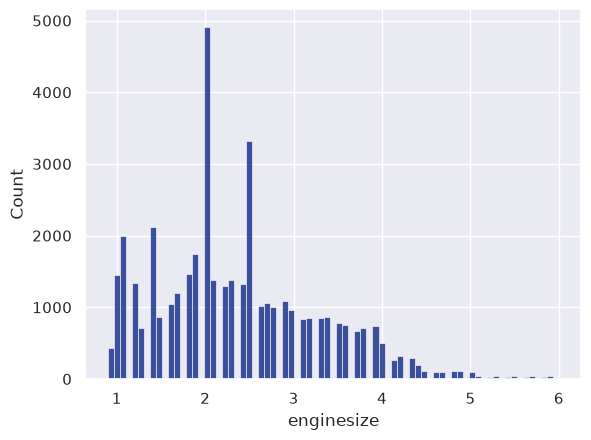

In [31]:
sns.histplot(df["enginesize"]);

---
## Mileage in km
- The maximum mileage by a car is 320262, and the minimum mileage is 1081
- The average mileage from the data appears to be 157748 
- There is no other feature disturbing the car mileage, as it purely depends on how much it is being used

In [32]:
df["mileage"].describe()

count     42708.000000
mean     157748.894985
std       86676.836561
min        1081.000000
25%       82781.250000
50%      158526.000000
75%      232639.750000
max      320262.000000
Name: mileage, dtype: float64

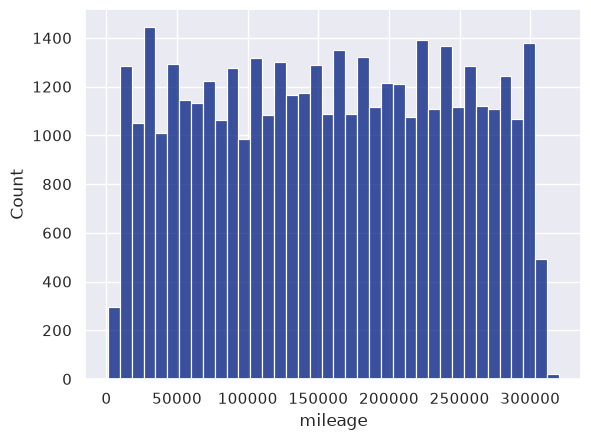

In [33]:
sns.histplot(df["mileage"]);

---
## Cars Age
- The max age is 20 while min is 1
- The average is 10

In [34]:
df["carage"].describe()

count    42708.000000
mean        10.516320
std          5.768721
min          1.000000
25%          6.000000
50%         11.000000
75%         15.000000
max         20.000000
Name: carage, dtype: float64

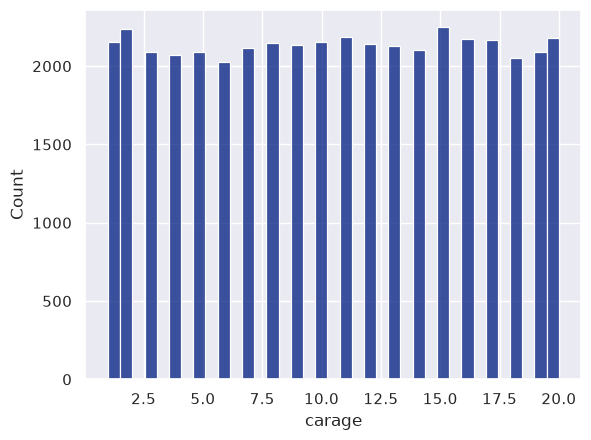

In [35]:
sns.histplot(df["carage"]);

---
## Brand
- There are about 16 unique brands in 42708 cars
- The most frequently occurring brand is Toyota, which has occurred about 5443 times
- The least occurring brands are Fiat and Peugeot, with Fiat being the lowest one
- Also, the graph shows unevenness where some brands (Toyota, Audi, BMW, Mercedes-Benz) occur more often, while several brands (Fiat, Peugeot, Dacia, 
  Chevrolt) appears far less often.
  

In [36]:
df["brand"].describe()

count      42708
unique        16
top       Toyota
freq        5443
Name: brand, dtype: object

In [37]:
df["brand"].value_counts()

brand
Toyota           5443
Audi             4421
Mercedes-Benz    4411
BMW              4096
Mazda            3375
Porsche          3313
Hyundai          3196
Ford             2989
Volkswagen       2305
Kia              2220
Honda            2185
Chevrolet        1127
Renault          1123
Dacia            1068
Peugeot           723
Fiat              713
Name: count, dtype: int64

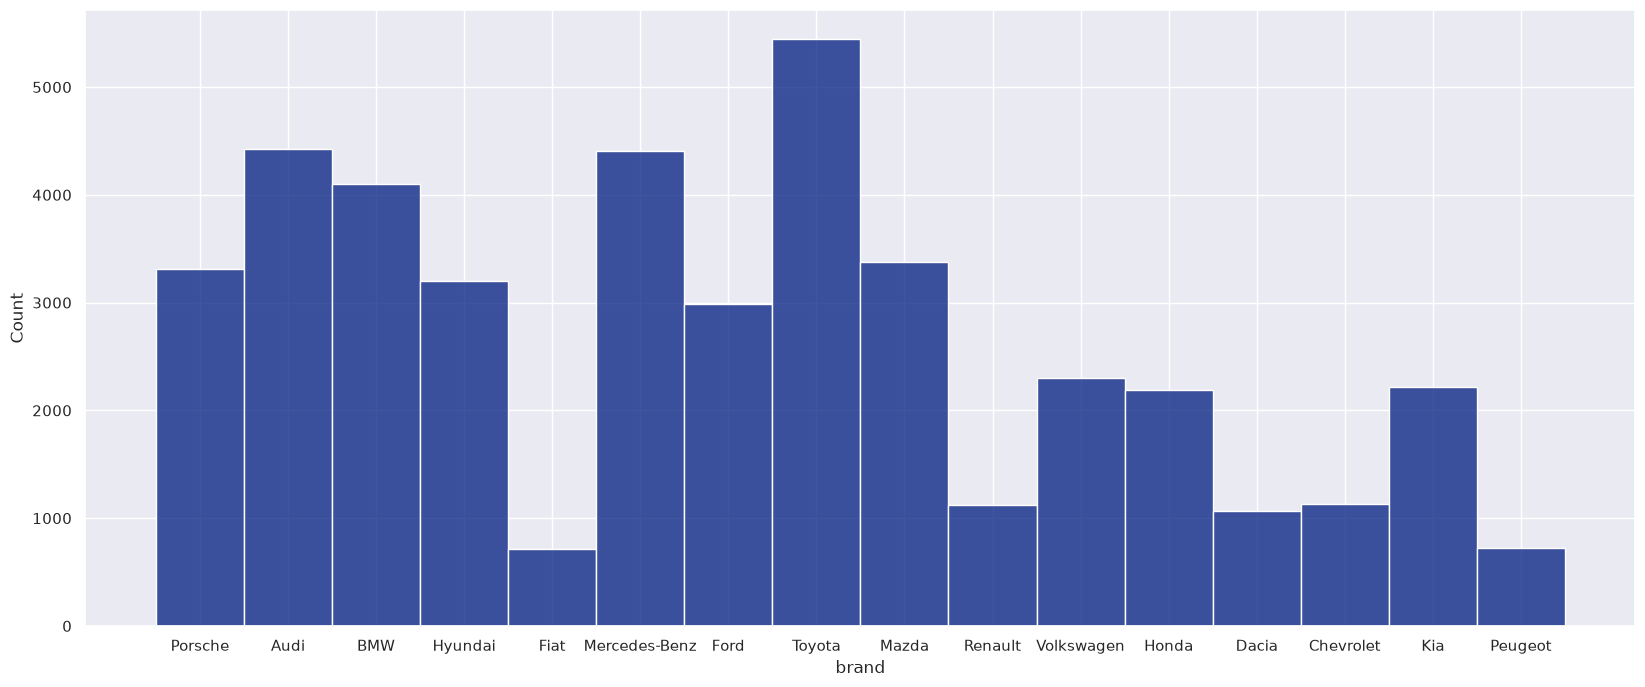

In [38]:
plt.figure(figsize=(20,8))
sns.histplot(df["brand"]);

---
## Fuel Type
- Most of the cars mentioned are running on Gasoline up to 30799
- Hybrid being 9875
- And Diesel being 2034
- Distribution is heavily skewed toward Gasoline — it makes up about 72% 
  of the dataset, while Diesel is under 5%
- As with the brand, comparisons involving Diesel later should be treated 
  With some caution, given the small sample size

In [39]:
df["fueltype"].describe()

count        42708
unique           3
top       Gasoline
freq         30799
Name: fueltype, dtype: object

In [40]:
df["fueltype"].value_counts()

fueltype
Gasoline    30799
Hybrid       9875
Diesel       2034
Name: count, dtype: int64

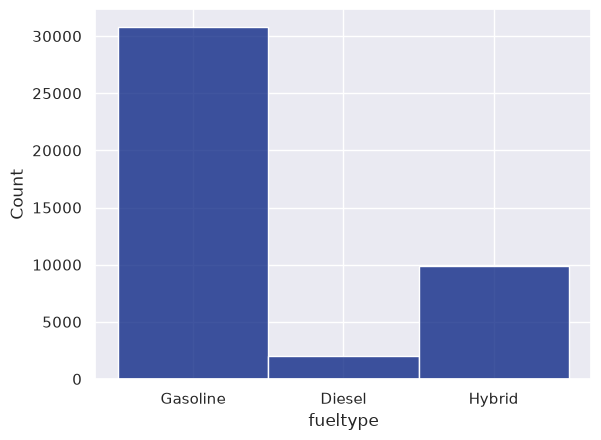

In [41]:
sns.histplot(df["fueltype"]);


# Bivariate and Multivariate Analysis:

## Price and Insurance Relationship

### Does the Insurance affect the prices of the car?
- The insurance of the cars does not affect the prices, as confirmed by the box plot
- Both boxplots appear to be identical to each other.
- The average, max, and min are quite similar to each other, and even outliers have almost little to no difference

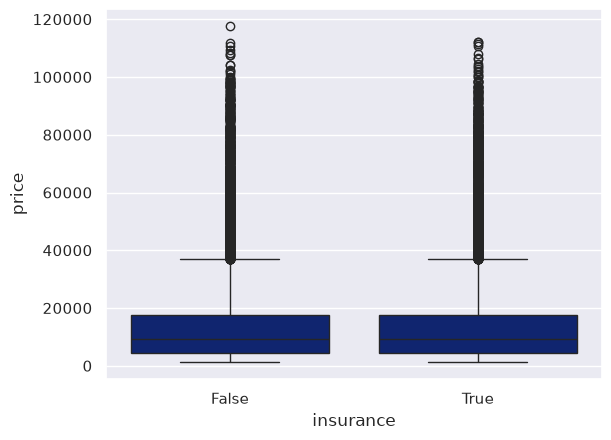

In [42]:
sns.boxplot(data=df, x="insurance", y="price");

***
## Price and Accident History Relationship

### Does the Accident of the car affect the prices?
- The accident does affect the prices of the car, as can be visualized on the graph.
- Cars with accidents have a significant price drop compared to those without accidents.
- Although the minimum prices are not affected that much, as we go higher, cars with higher prices are less likely to have an accident, yet it can be one of the causes.
- Average prices also drop significantly with accidents.
- The highest price outliers (above ~$95,000) appear almost exclusively in the no-accident group, suggesting premium or luxury cars in this dataset rarely carry an accident history.

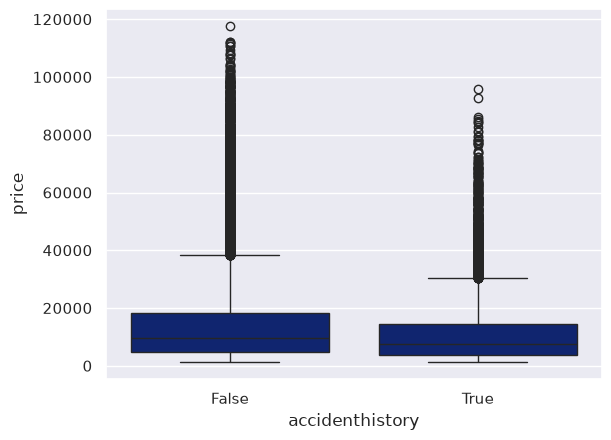

In [43]:
sns.boxplot(df, x=df["accidenthistory"], y=df["price"]);

***
## Price and Fuel Efficiency Relationship

### Does the Fuel Efficiency affect the Prices?
- No clear linear relationship is visible — high and low-priced cars appear across the full fuel efficiency range
- The densest concentration of cars sits between 8-14 L/100km, mostly priced under $30,000
- Fuel efficiency alone does not appear to be a strong predictor of price in this dataset

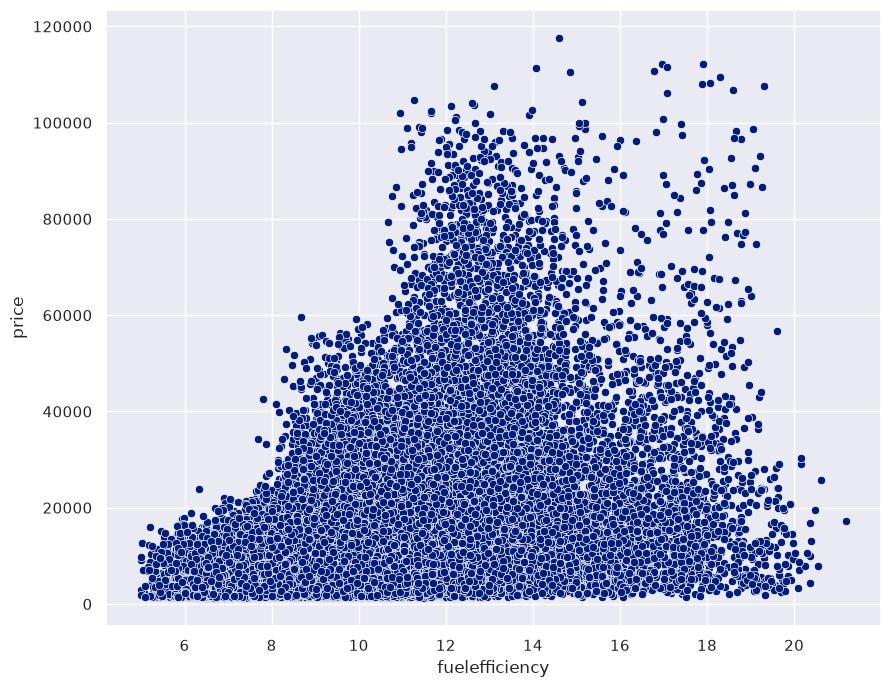

In [44]:
plt.figure(figsize=(10,8))
sns.scatterplot(df, x=df["fuelefficiency"], y=df["price"]);

In [45]:
df["fuelefficiency"].quantile(0.90)

np.float64(13.93)

***
## Price and Fuel Type Relationship

### Does the fuel type affect the prices?
- Diesel cars show the highest typical price range despite being the smallest group, while Gasoline cars dominate the dataset but sit at a lower typical price point
- The Gasoline has most of its cars sitting in range from 5500 to 18000, average being 8636 with minimum being 1249, and a maximum of 112278
- The Diesel has most of its cars sitting in the range from 7500 to 28000 average being 13633, minimum being 1402, and maximum being 58486
- The Hybrid have most of its car sitting in range from 6500 to 19700 average being 10016, minimum being  1257 and maximum being 117598
- The highest price outliers (above ~100,000) appear exclusively in Gasoline and Hybrid groups Diesel cars cap around 58,000 - 60,000. 
- This likely reflects that ultra-luxury manufacturers (Porsche, Ferrari, etc.) predominantly produce Gasoline or Hybrid engines rather than Diesel.
- Numerically confirmed: Diesel has the highest median price (13,633) but the lowest maximum (58,486), while Gasoline and Hybrid have lower medians (8,636 and 10,016) but reach much higher    price ceilings (112,278 and 117,598 respectively)


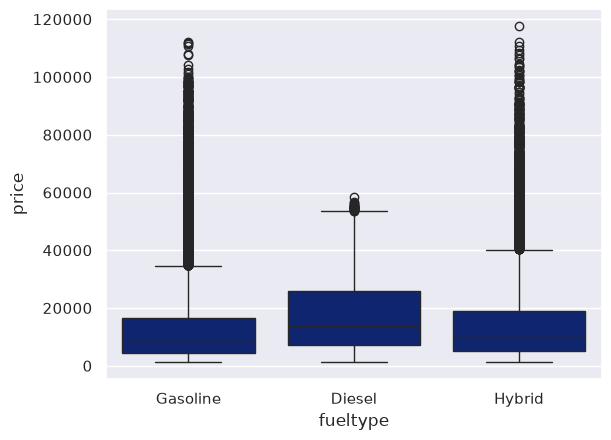

In [46]:
sns.boxplot(df, x=df["fueltype"], y=df["price"]);

In [47]:
df.groupby("fueltype")["price"].min()


fueltype
Diesel      1402
Gasoline    1249
Hybrid      1257
Name: price, dtype: int64

In [48]:
df.groupby("fueltype")["price"].max()

fueltype
Diesel       58486
Gasoline    112278
Hybrid      117598
Name: price, dtype: int64

In [49]:
df.groupby("fueltype")["price"].median()

fueltype
Diesel      13633.0
Gasoline     8636.0
Hybrid      10016.0
Name: price, dtype: float64

***
## Price and Transmission Relationship

### Does Transmission Affect Prices
- The Transmission does not appear to have that much of an effect on prices, as can be seen, both box plots are quite similar.
- The median, max, and min all have little to no difference between each other, with a 7 percent max.
- Automatic median being 9173, max being 112278, min being 1249
- Manual median being 9090.0, max being 117598, min being 1257 
- So we can safely assume that transmission does not appear to have any effect on prices

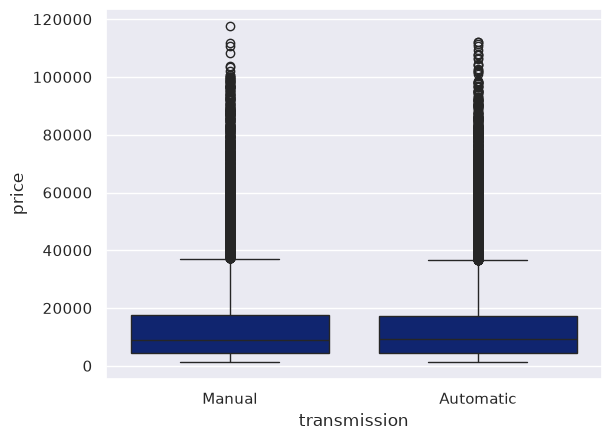

In [50]:
sns.boxplot(data=df, x="transmission", y="price");

***
## Price and Mileage Relationship

### Does the mileage affect the price of a car?
- The Mileage is one of the strongest features affecting the prices of cars, showing a negative relationship, as can be seen in the graph
- The trend in the graph shows that when the mileage increases, the prices decrease
- The cars with Mileage above 250000 km appear to have prices less than 20000 USD, the least in the graph
- The relationship is curved, where cars with less than 50000 km mileage show the widest price range, up to 120000 USD
- The pattern forms a triangular shape, suggesting mileage acts as a price ceiling. High mileage limits how expensive a car can be, but low mileage    alone doesn't guarantee a high price 


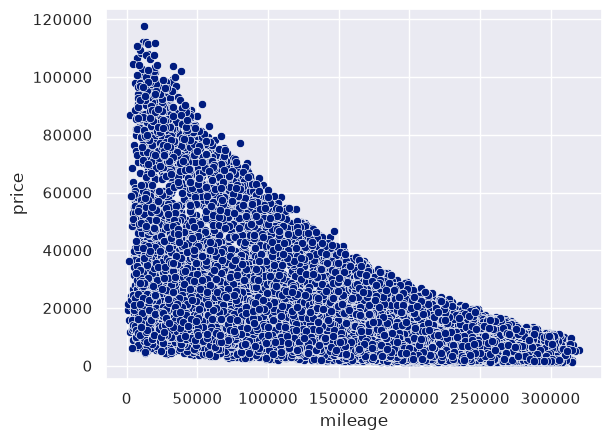

In [51]:
sns.scatterplot(df, x="mileage", y="price");

---
## Price and Body Type Relationship

### Does the body type affect the prices?
- Coupe commands the highest typical price (median 14,971 USD), followed by Sedan (11,902 USD), while Hatchback (4,613 USD) and Convertible (8,189 USD) sit at the lower end
---
- The Sedan is the most dominant body type in the dataset, with 17309 cars
- The average price of Sedan is 11902.0, with a max of 117598 and a min of 1355
- The Sedan has the most expensive car with a price of 117598 USD, but despite that, it has the second-highest price range for most of its cars (Coupe being in first)
***
- The Hatchback is the Second dominant body type in the dataset, with 10198 cars
- The average price of Hatchback is 8893, max being 22886, min being 1249 (the lowest price car in the dataset)
- Despite the large numbers, its range of prices is much more compact than others, suggesting that this body type may have the most stable prices.
- It also suggests that the cars with most low average prices (under 20000 USD ) can be found in the Hetchback body type
***
- The SUV is the third dominant body type in the dataset, with 8893 cars
- The average price of a SUV is 9809, with a max of 61305 and a min of 1285
- Most of its car prices range under 20000 USD
***
- The Coupe is the Fourth dominant body type in the dataset, with 4409 cars
- The average price of Coupe is 14971.0, with a max of 103998 and a min of 1464
- This body type is interesting, why? because this body type has the highest range of prices for most of its cars, ranging from 9000 USD to 28000 USD
- Worth noting that Coupe has the highest median price of all body types (14,971)
***
- Convertible (1,117 cars) and Pickup (783 cars) have too few records for reliable conclusions
- their price ranges suggest budget positioning but sample sizes limit confidence.


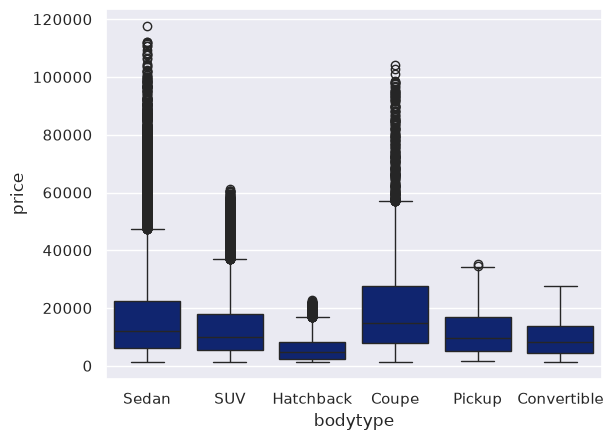

In [52]:
sns.boxplot(df, x="bodytype", y="price");

---
## Price and Horsepower Relationship

### Does Horsepower affect the prices?
- The graph shows an interesting relationship between price and horsepower.
- It suggests that the lower horsepower assures that the cars will have low prices, but also at the same time it denies the assurance that cars with high horsepower will have high prices
- Lower-horsepower cars under 150 are mostly priced less than 20000, while high-horsepower cars spread across the full price range
- Most of the cars in the dataset have horsepower ranging from 100 to 350. It also strengthens our claim that there are more lower-priced cars in the dataset
- This confirms that horsepower acts as a price floor rather than a price ceiling — low HP limits price downward, but high HP alone doesn't push price upward


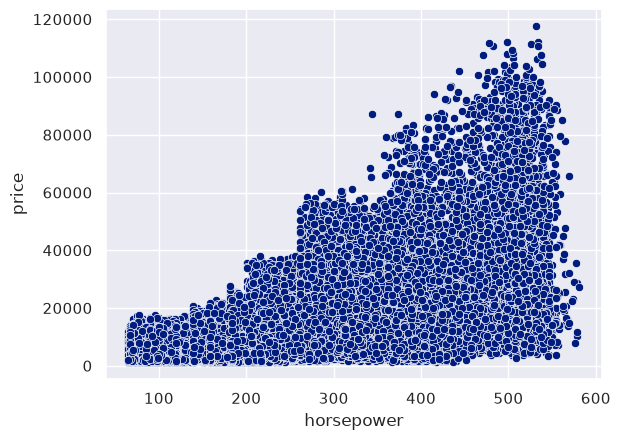

In [53]:
sns.scatterplot(df, x="horsepower", y="price");

In [54]:
df["horsepower"].quantile(0.75)

np.float64(364.0)

---
## Price and Age of Car Relationship

### Does the age of a car affect the prices?
- The age of cars does have an impact on prices — older cars are priced significantly lower, while younger cars span the full price range
- Younger cars (age 1-3) show the widest price range and do not guarantee a higher price
- It states that the age of the car is a price ceiling
- Cars aged 10 or under (roughly half the dataset, median age = 11) show the widest price range from near zero up to 117,598 USD
- The depreciation pattern here is notably more consistent than mileage each additional year removes roughly 5,000-8,000 USD from the maximum possible price

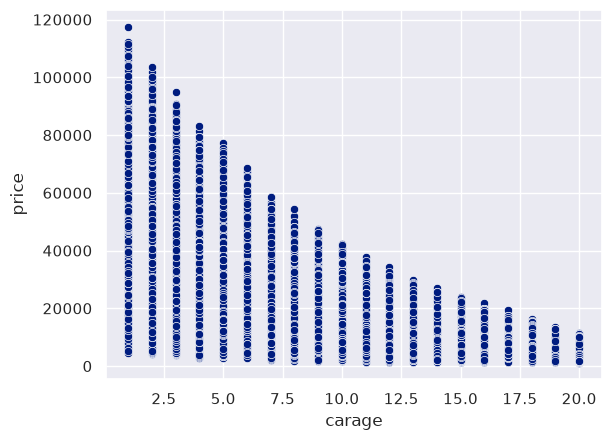

In [55]:
sns.scatterplot(df, x="carage", y="price");

In [56]:
df["carage"].quantile(0.50)

np.float64(11.0)

In [57]:
df.groupby("carage")["price"].max().sort_values(ascending=False)

carage
1     117598
2     103725
3      95076
4      83034
5      77130
6      68753
7      58677
8      54554
9      47642
10     42360
11     37763
12     34203
13     29774
14     27103
15     23936
16     21921
17     19286
18     16241
19     13434
20     11436
Name: price, dtype: int64

---
## Price and Brand Relationship

### Does the Brand of a Car affect the prices?
- Four car brands (Porsche, Mercedes-Benz, Audi, BMW) have the cars with the most impact on prices in this dataset
- The dataset shows a clear two-tier market: luxury brands (Porsche, Mercedes-Benz, Audi, BMW) with medians above 16,000 USD, and mainstream brands (Toyota, Mazda, Honda, Hyundai, etc.) with medians under 8,000 USD, roughly half the typical price
***
- Porsche shows the widest range of car prices from the dataset, with a median of 23742 USD. Other brands also show these wide ranges, such as Mercedes-Benz being 2nd with a median of 18178 USD, Audi 3rd with a median of 16892 USD, and BMW 4th with a median of 16620.5 USD
- Mercedes-Benz contains the most expensive car (model: S-Class) 117598 USD, while Hyundai has one of the cheapest cars (model: i10) 1249 USD, from the dataset
- Toyota, despite having the largest number of cars, shows very little range of prices, with the median being 6932.0 USD, the maximum being 42527 USD, and min being 1350 USD
- Other brands, such as Mazda, Hyundai, Ford, Volkswagen, Kia, Honda, also show a similar pattern to Toyota, despite being one of the brands with more than 20000 cars
The remaining brands, Chevrolet, Renault, Dacia, Peugeot, and  Fiat, have way fewer cars compared to other brands, to deduce some info out of them, yet these brands also show a little range of prices in the dataset         

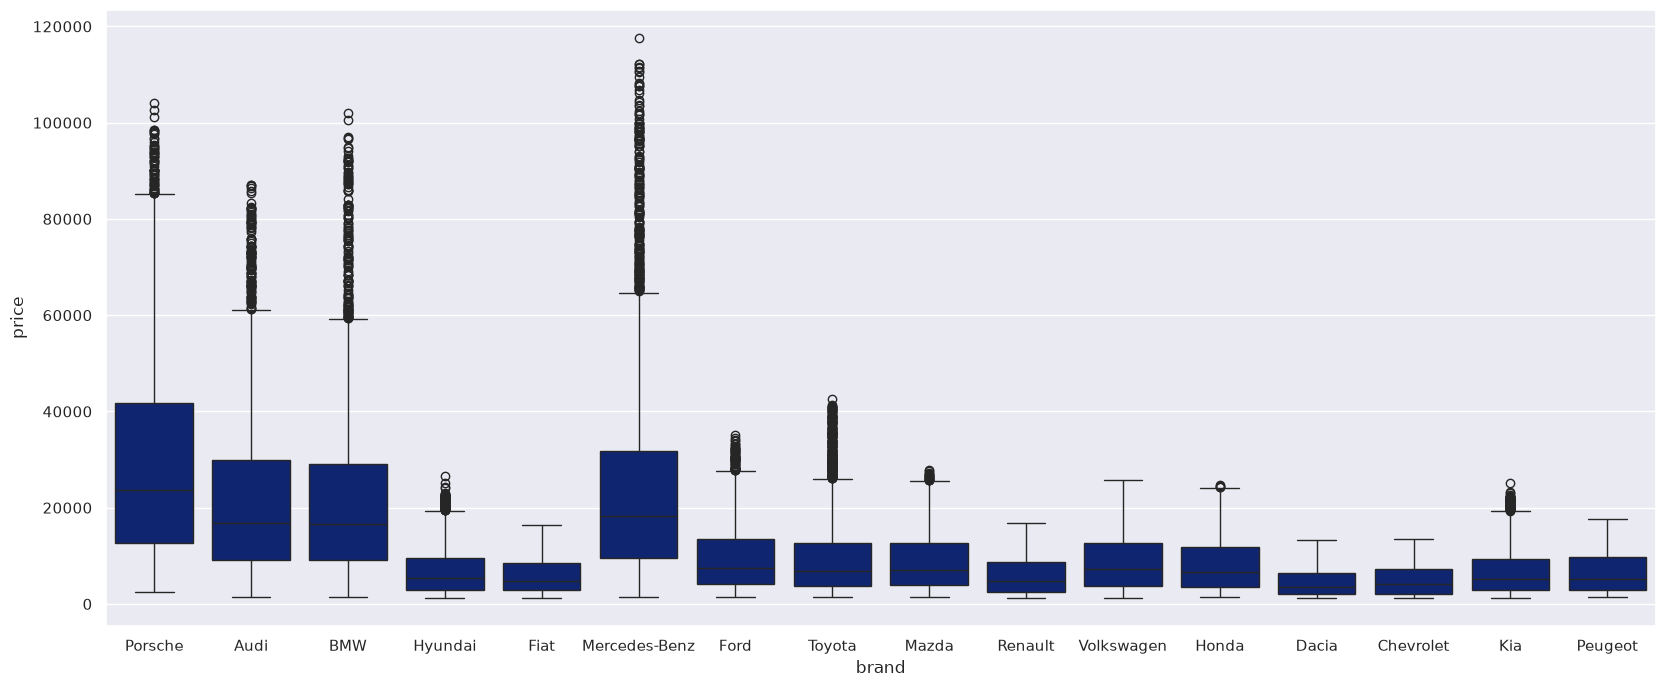

In [58]:
plt.figure(figsize=(20,8))
sns.boxplot(df, x="brand", y="price");

---
## Price and Condition Relationship

### Does the condition affect the price of a car?
- Well, not surprised here because it was obvious from the get-go that conditions do affect the prices
- Although the number of damaged cars is way less than used cars, their price range is still less than half of the used cars, with a median of 5126.0 USD, while used cars have a median of 9686.0 USD
- The maximum price for Damaged cars caps around 65,000 USD, while used cars reach up to 120,000 USD — luxury-tier pricing is essentially exclusive to used condition cars in this dataset
- Number of damaged cars is 4295, and used cars are 38413

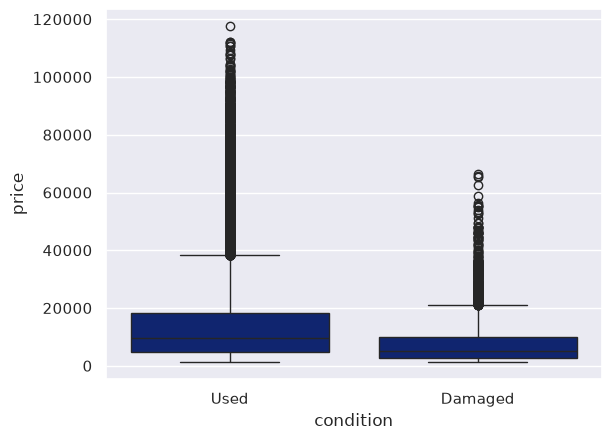

In [59]:
sns.boxplot(df, x="condition", y="price");

---
## Fuel Type and the Brand Relationship

### Which Brand Produces which kind of Fuel Type?
- Only three of the brands have cars running on Diesel (Audi (559), Mercedes-Benz (1106), and Peugeot (369))
- BMW and Renault show the most balanced Gasoline/Hybrid split BMW (2088 vs 2008) and Renault (576 vs 547) suggesting these brands lean more toward hybrid technology than others
- Chevrolet, Dacia, Mazda, and Volkswagen have cars with only Gasoline as a fuel type from the dataset
- Chevrolet, Dacia, Mazda, Peugeot, and Volkswagen have no hybrid cars in this data set
- Mazda, Chevrolet, Dacia, and Volkswagen are purely Gasoline brands with zero Hybrid or Diesel cars in this dataset
- BMW and Toyota have more than 2000 hybrid cars, while Hyundai and Mercedes-Benz have more than 1000 hybrid cars; the remaining brands have no or fewer than 602 cars
- Despite Toyota being a brand with most of the cars in this dataset, Mazda still has more cars running on Gasoline, because it has no car running on diesel or is a hybrid, while Toyota has most hybrid cars, followed by BMW

In [60]:
df["fueltype"].value_counts()


fueltype
Gasoline    30799
Hybrid       9875
Diesel       2034
Name: count, dtype: int64

In [61]:
pivot=df.groupby(["brand", "fueltype"]).size().unstack(fill_value=0)


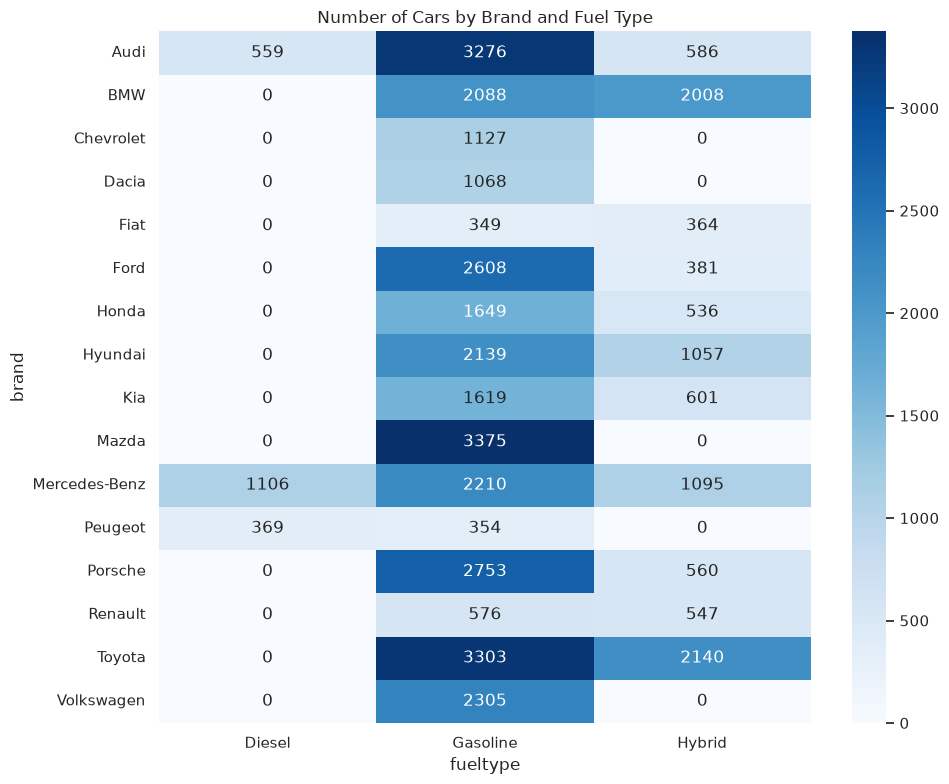

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Number of Cars by Brand and Fuel Type")
plt.tight_layout()
plt.show()

---
## Price, Year and Brand Relationship

### What are the changes in prices of each brand over the years?
- The top 5 brands that had the most impact on the dataset and showed the most varied prices are selected to visualize their change in price over the years
- These striking visualizations show a variety of informations
- Porsche prices were dominant from the get-go and increased pretty consistently over the years, maintaining its lead over other brands
- Followed by Porsche, Mercedes also showed similar behaviour and a similar increase in prices over the years
- Although the pattern is similar, Mercedes still showed a wider range of prices than Audi after 2017
- Audi and BMW were neck to neck, showing similar prices and a similar range of those prices, although each of them had its turns of being dominant in some of those years
- Toyota, despite having the largest number of cars in the dataset, still had the lowest priced cars among the top 5 brands, with the least range of prices. It also showed a consistent increase in prices over the years
- Before 2010, all five brands showed relatively similar price levels. The clear separation into luxury vs mainstream tiers became increasingly pronounced after 2010, and accelerated sharply post-2017
### Note: These are the prices of used cars, which do not depict the market value of any of the mentioned brands.

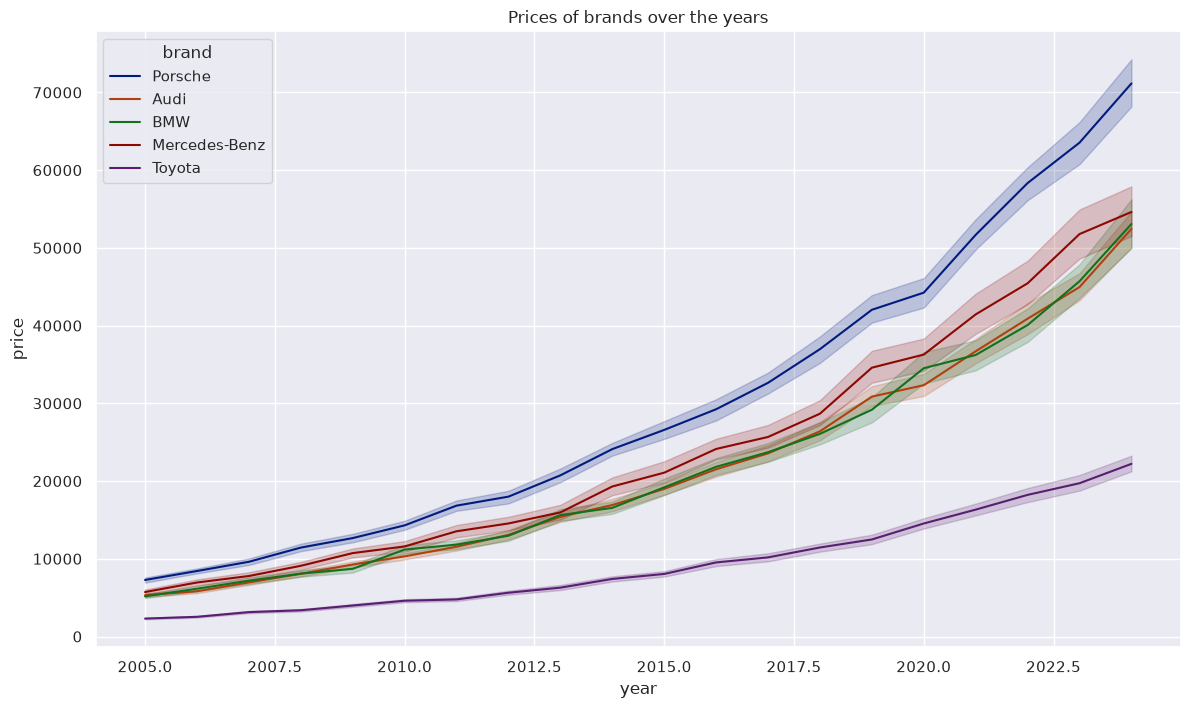

In [63]:
df_top=["Porsche","Toyota","Mercedes-Benz","Audi","BMW"]
top_brands=df[df["brand"].isin(df_top)]
plt.figure(figsize=(14,8))
sns.lineplot(top_brands, x="year", y="price", hue="brand")
plt.title("Prices of brands over the years")
plt.show()

# Heat Map of the studied Features

## This heat map shows the relationship/correlation between many of the important numeric features that have already been analysed.
- We can safely assume the numeric features of the dataset have been divided into two parts, with two features (Mileage, and Car age) negatively affecting the prices, while (Engine Size, Torque, Horsepower) positively affect the Prices + Fuel Efficiency, showing a  weak positive affect on prices
- Note: We did not include categorical features for this conclusion
***
- The relationship of Mileage and Price in the heatmap is exactly as depicted earlier, with the help of a box plot showing a strong negative correlation and suggesting that the increase in mileage decreases the Price
- Horsepower and prices show a positive correlation, as shown in bivariate analysis, and also show that horsepower and mileage are exact opposites to each other, as an increase in horsepower also shows the trend of an increase in prices
- The engine size that was not analysed earlier also shows a positive correlation, which suggests that an increase in engine size also increases the prices
- Car age also shows a negative correlation, which makes sense as the older the car is, the lower its price will be. It also matches our previous findings
- Fuel efficiency shows the weakest positive correlation with price (0.41), consistent with our earlier scatter plot finding of no strong, clear relationship
- Torque, which was not analyzed previously it also shows a similar pattern to fuel efficiency; the more the torque, the greater the price
- Another interesting relationship from this heatmap is Mileage and Car age, which shows perfect positive correlation, and it also makes sense as obviously the greater car age would also imply that the car had  travelled a lot too (Mileage)
- Engine Size, Torque, Horsepower,r and Fuel Efficiency are all positively correlated to each other, as all of them show strong positive correlation with each other, which makes sense because all of their increases the value

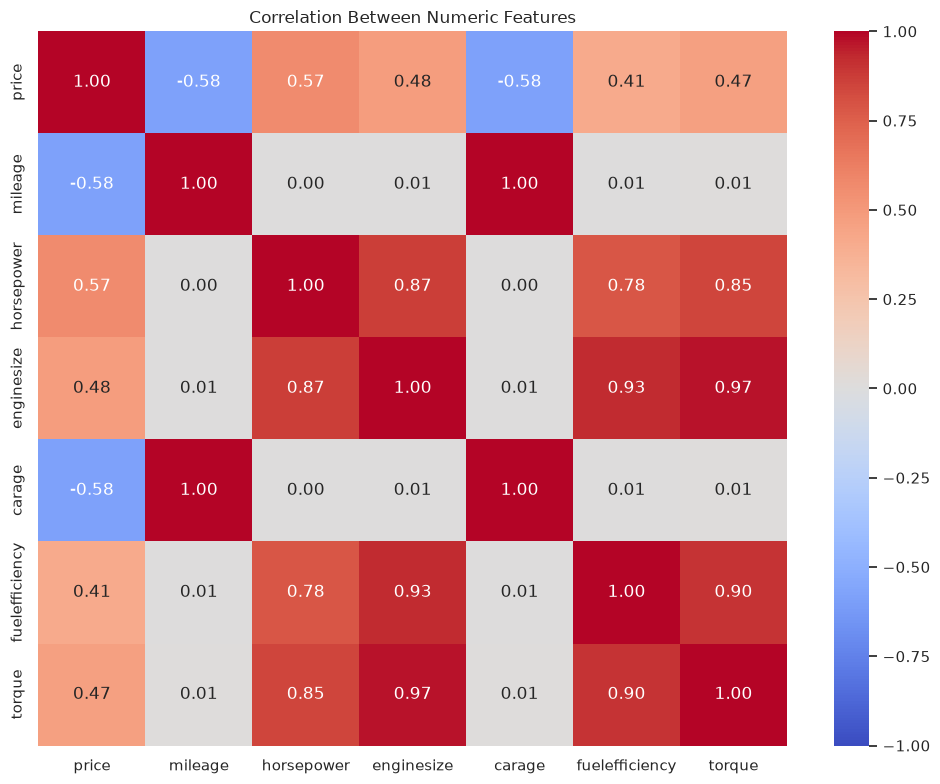

In [64]:
numeric_cols = ["price", "mileage", "horsepower", "enginesize", 
                "carage", "fuelefficiency", "torque"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), 
            annot=True, 
            cmap="coolwarm", 
            vmin=-1, vmax=1, 
            fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

# Key Findings:

- __Insurance__ has literally no effect on the prices, which was surprising, as the insurance should have added some value to a car, so we can safely rule it out as a price predictor

- __Accident History__ does seem to have an impact, as higher-priced cars are less likely to have an accident history

- __Fuel Efficiency__ has a weak positive correlation, and also at the same time showing that about 90 percent of the cars have fuel efficiency under 14, with a range of prices scattered all over the data ("Mostly under 30,000")

- __Fuel Type__ shows that the Diesel was the least produced car, but showed the highest range of price, yet Gasoline and Hybrid had cars with the highest prices in the dataset, implying that most of the brands prefer to manufacture luxurious cars with fuel type as Gasoline or Hybrid

- __Transmission__ is the same as the insurance, adding no value to a price, implying that we can also get rid of it

- __Mileage__ shows pretty insane numbers as increased mileage decreases the price; however, at the same time, decreased mileage does not guarantee an increase in price, as many other features that are different for different cars increase the range of price for decreased mileage

- __Body Type__ Sedan is a body type with the most abundant cars, also with one of the most expensive ones, followed by Hatchback with the most compact range of prices. SUV third most dominant, and Coupe has the highest median price despite being the fourth most common body type. The other two body types had no obvious information about them due to having way fewer cars compared to the other body types

- __Horsepower__ is an interesting find as it shows the same pattern as mileage, but in the opposite direction,  as decreased horsepower decreases the prices; however, at the same time, increased horsepower does not guarantee an increase in prices, as many other features that are different for different cars increase the range of prices for increased horsepower

- __Car Age__ It shows a depreciation pattern, removing roughly 5000 to 8000 with the increase of each year, and car ages between (1-3) show the widest range of prices, and does not guarantee a high price, as other features may also be involved

- __Brands__ such as Porsche, Mercedes-Benz, Audi, and BMW are the ones that moved the prices the most, with Porsche showing the widest range and Mercedes-Benz having the most expensive cars. These are also the only brands with cars above 50000 USD, and Toyota is the brand with the most cars in this dataset

- __Used, and damaged cars__ have a significant impact on prices as damaged cars' price range is half compared to used ones. Also, the maximum cap of used cars is also way higher than that of damaged cars, implying that expensive cars are only exclusive to the used car group

- __Fuel Type in Brands__ such as diesel is only found in three of the brands: Audi, Mercedes-Benz, and Peugeot. Mercedes and Audi are also the only ones with all fuel types available in their cars. Renault and BMW have balanced between Hybrid and Gasoline, implying they are more focused on hybrid-type cars compared to other brands that have no Hybrid type, and most of them have no Diesel

- __Prices of the Brands over the years__ showed a consistent increase. They all started with similar prices, but Porsche increased the distance over the year and took the lead, followed by Mercedes-Benz than Audi and BMW neck to neck, and at last toyota most range of prices was shown by Mercedes-Benz over the years

# Limitation:
- This notebook contains the analysis and relationship of features for used cars running on fuel, which implies that the scope is limited and does not involve new cars or cars running on electricity.

- This dataset was taken from Kaggle; although many things were already cleaned and checked before analysis, there are still some things that can act as a bias. This may include region as different regions have different prices; the branding was biased, as some brands did not have enough cars to conclude a insight from them; some other factors which were not in the dataset can also contribute to dataset bias.

- Additionally, if we had region, then it would make the notebook much more meaningful and accurate, and other features like ground clearance could have also contributed to the prices of the dataset

- Although many features show positive and negative correlation, other factors that could have been accounted for can also cause this correlation, but due to the limitations of the dataset, that is all we can conclude

- Some brands and fuel types are significantly underrepresented. Diesel cars (2,034 records) and brands like Fiat (713) and Peugeot (723) have too few records for reliable conclusions, which limits the generalizability of findings involving these groups

# Future Work:
- We have left the option column as it is, although it may be used for future purposes when needed
- There are many redundant correlations, such as mileage and carage, which are almost perfectly positively correlated to each other; also, features like torque and engine size. This redundancy implies that one of these features can be dropped safely for an ML model; also, features such as transmission and insurance, which have little to no effect, can also be dropped for future work
- This cleaned and analysed data can then be data engineered and fed to the linear regression or some other ML model to predict the prices of used cars based on analysis made on this dataset
- The scope of the dataset could also be expanded in the future, adding electric cars and new cars for separation analysis and seeing the dynamics of prices across all vehicle types

# Conclusion

One of the most surprising findings from this analysis was that transmission type and insurance status had virtually no effect on 
price. Initially, I expected automatic cars to command a premium over manual, and insurance to add some value. Neither turned out to be true. Equally surprising was the near-identical but opposite relationship between mileage and horsepower with price: both form a wedge pattern, but mileage acts as a price ceiling (high mileage limits how expensive a car can be) while horsepower acts as a price floor (low horsepower prevents high prices). Finding the same pattern in mirror image across two different features was unexpected.

The three features that most consistently influenced price were mileage, car age, and brand, all showing strong relationships confirmed both visually and through correlation analysis. Horsepower and condition also proved meaningful.

This analysis provides a strong foundation for future work. The next step can be feature engineering, finding the correlation between the features before building a predictive ML model. An Ml model model trained on the cleaned dataset could provide reliable used car price estimates, which would be valuable for buyers, sellers, and dealerships alike.